In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [9]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 2, 2
l1_1, l2_1 = 1, 3
j1_0, j2_0 = 3/2, 5/2



if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  

energy_unit = 'MHz'
    

In [10]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

   Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  ...  \
0           3    45     2   1.5    51     2   2.5    46     1   0.5  ...   
1           2    45     2   1.5    51     2   2.5    46     1   0.5  ...   
2           6    47     2   1.5    54     2   2.5    48     1   1.5  ...   
3           4    53     2   1.5    60     2   2.5    54     1   0.5  ...   
4           5    53     2   1.5    60     2   2.5    54     1   0.5  ...   
5           8    54     2   1.5    62     2   2.5    55     1   1.5  ...   
6           0    59     2   1.5    57     2   2.5    61     1   0.5  ...   
7           1    59     2   1.5    57     2   2.5    61     1   0.5  ...   
8           7    61     2   1.5    69     2   2.5    62     1   0.5  ...   

   change1  change2     defect       c3k  asymmetry 10um  energy 10um  \
0        1       -2  19.646767 -3.890497     -143.490614    -0.379007   
1        1       -2  26.702835 -1.004522     -143.752471    -0.379699   
2        1       -2 

In [12]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
f1_1, f2_1 = 1, 1

btunes = np.unique(magTune_import(atom1, n1_0, l1_0, j1_0, atom2, n2_0, l2_0, j2_0, l1_1, l2_1))

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=-j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=-j2_0)

bfield = 0  # Gauss

from pairinteraction.visualization.colormaps import alphamagma
import os

maxb = 80
minb=0
num=500
magnetic_fields = np.linspace(minb,maxb,num)
n_dif = 3
jdif = 3
ldif = 3
e=0
energy_unit = 'MHz'


Magnetic file doesn't exist


In [13]:
n_dif=3
ldif=3
jdif=3
def get_system_pair_list_b(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, b_fields: np.ndarray, d, erange
) -> list[pi.SystemPair]:
    
    basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

    basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))

    pair_systems = []
    for i, e in enumerate(b_fields):
        system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,e], unit='G'), pi.SystemAtom(basis2).set_magnetic_field([0,0,e], unit='G')

        if i == 0:
            pair_energy = ket1.get_energy(unit=energy_unit) + ket2.get_energy(unit=energy_unit)

        pi.diagonalize([system1, system2])
        # print(f'pair energy = {pair_energy}{energy_unit}')
        min_energy, max_energy = pair_energy - erange, pair_energy + erange
        
        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(d, unit='um')
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )

    return pair_systems, states_num


In [21]:
magnetic_fields_nums = [2]
nums_b_fields_sub = list(magnetic_fields_nums)[::2]

b_fields_sub = [2]
r = [5000]

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)


mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
mj1_1s, mj2_1s = np.arange(-j1_1, j1_1+1), np.arange(-j2_1, j2_1+1)
mj1_1_1s, mj2_1_1s = np.arange(-j1_1, j1_1+2), np.arange(-j2_1, j2_1+2)

bfield = 0  # Gauss
erange = abs(defect*6)
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
for d in r:
    pairs = get_system_pair_list_b(ket1, ket2, b_fields_sub, d, erange)
    system_pairs_dict[d] = pairs[0]
    states_num = pairs[1]


print(system_pairs_dict)

{5000: [SystemPair(BasisPair(|~Rb:54,P_1/2,-1/2; Cs:58,F_7/2,-7/2⟩ ... |~Rb:53,D_3/2,3/2; Cs:60,D_5/2,5/2⟩), is_diagonal=True)]}


[-9.54451466 -7.30606318 -6.18014169 -3.94169021 -2.81777835 -0.57932711
  0.54259777  2.78104925  3.90100765  6.13945913  7.25747156  9.4959228 ]
[-17.92774391 -16.06373358 -14.85804939 -12.9940393  -11.76137042
  -9.89736032  -8.62753487  -6.76352477  -5.43771815  -3.57370806
  -2.14828944  -0.28427935   1.4237957    3.28780603]


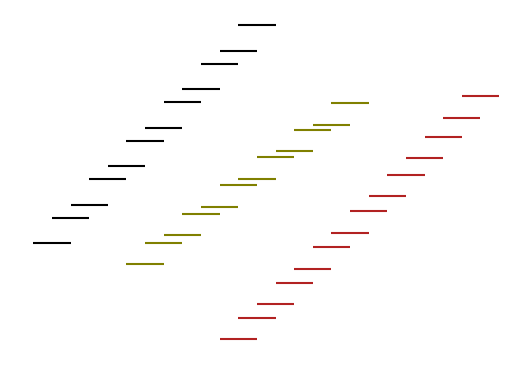

In [73]:


for i, d in enumerate(r):
    fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
    ax.set_ylabel(f"Energy ({energy_unit})")
    # ax.set_ylim(-0.01, 0.01)

    # system_atom = system_atom_dict[efield]
    pair_energy = ket1_energy + ket2_energy
    system_pairs = system_pairs_dict[d]


    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in system_pairs]    
    
    plt.tight_layout()
  
    plt.ylabel(f"Energy [{energy_unit}]")
    min_overlap = .8
    levels = []
    for m1 in mj1_1s:
        for m2 in mj2_1s:
            ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1, j=j1_0)
            ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2, j=j2_0)   
            overlaps = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]
            for x, es, os in zip(b_fields_sub, energies, overlaps):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                levels.append(es[inds])

    levels = np.array(levels).flatten()
    levels = np.sort(levels, axis=0)
    for i, level in enumerate(levels):
        plt.hlines(level, xmin = i, xmax = i+2, color='0', linewidth=1.5)
    print(levels)
    levels = []
    for m1 in mj1_1s:
        for m2 in mj2_1s:
            ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1)
            ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=m2)

            overlaps = [system.get_eigenbasis().get_overlaps([ket1_1, ket2_1]) for system in system_pairs]
            for es, os in zip(energies, overlaps):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                levels.append(es[inds])
    
    levels = np.array(levels).flatten()
    levels = np.sort(levels, axis=0)
    for i, level in enumerate(levels):
        i=i+5
        plt.hlines(level, xmin = i, xmax = i+2, color='olive', linewidth=1.5)


    mj2_1_1s = np.arange(-j2_1, j2_1+2)
    levels = []
    for m1 in mj1_1s:
        for m2 in mj2_1_1s:
            ket1_1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1)
            ket2_1_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1+1, m=m2)
            overlaps = [system.get_eigenbasis().get_overlaps([ket1_1_1, ket2_1_1]) for system in system_pairs]
            for es, os in zip(energies, overlaps):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                levels.append(es[inds])
                
    levels = np.array(levels).flatten()
    levels = np.sort(levels, axis=0)
    print(levels)
    for i, level in enumerate(levels):
        i=i+10
        plt.hlines(level, xmin = i, xmax = i+2, color='firebrick', linewidth=1.5)
    plt.axis('off')
    plt.xticks([])
    # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
    plt.show()
    # fig.savefig(path + f'level pairstate sep{r}.png')